# **MCZA018 – Processamento Digital de Imagens**

### **Laboratório 5 – Cores em Imagens e Vídeo**


### Este arquivo fornece códigos de funções úteis e necessárias para executar os roteiros das **(3) Atividades Práticas Experimentais** do Lab.5 - Cores em Imagens e Video, fornecido no arquivo pdi26__Lab5_img_colors_.pdf.

### 2. Pré-requisitos

* Python 3.x, NumPy, OpenCV e Matplotlib.
* Imagens coloridas `.png` ou `.jpg` de alta qualidade.

---

### 3. Atividades Práticas Experimentais

### 3.1. Correção de Ponto Branco (White Point Correction - 4.1.11)

A correção de ponto branco ajusta a iluminação para que objetos brancos pareçam brancos sob diferentes fontes de luz. Usaremos a transformação de von Kries:
$C_{new} = C_{old} \cdot (W_{target} / W_{source})$.

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def white_point_correction(img, sourcewp, targetwp):
    # img escala [0, 1]
    corrected = img * (targetwp / sourcewp)
    return np.clip(corrected, 0, 1)


In [ ]:
# Exemplo: Corrigindo de uma luz quente (amarelada) para D65 (luz do dia)
img = cv2.imread('messi5.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) /255.0

# Simplificação: canais R, G, B
source_wp = np.array([0.8, 0.8, 0.5])
target_wp = np.array([1.0, 1.0, 1.0])
corrected_img = white_point_correction(img_rgb, source_wp, target_wp)

# Mostra a imagem corrigida
plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.imshow(img_rgb) # Display the original image (normalized)
plt.title('Imagem Original RGB')
plt.axis('off')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.imshow(corrected_img)
plt.title('Imagem Corrigida (White Point)')
plt.axis('off')

plt.show()

### 3.2. Transformação XYZ para RGB e Correção Gama (4.1.12 e 4.1.13)

O espaço $XYZ$ é independente de dispositivo, mas para exibição em monitores, precisamos converter para $RGB$ e aplicar a lei de potência (Gama).

In [ ]:
def xyz_to_rgb_gamma(xyz_img):
    # Matriz de conversão linear XYZ para RGB (exemplo para D65)
    matrix = np.array([[3.2406, -1.5372, -0.4986],
                       [-0.9689, 1.8758, 0.0415],
                       [0.0557, -0.2040, 1.0570]])

    rgb_linear = xyz_img @ matrix.T
    rgb_linear = np.clip(rgb_linear, 0, 1)

    # Correção Gama (4.1.13): sRGB standard
    # Aproximação: C = 1.055 * L^(1/2.4) - 0.055
    gamma_corrected = np.where(rgb_linear <= 0.0031308,
                               12.92 * rgb_linear,
                               1.055 * np.power(rgb_linear, 1/2.4) - 0.055)
    return gamma_corrected

In [ ]:
# APLICANDO A CORREÇÃO GAMA EM UMA IMAGEM

# É necessário ter a imagem RGB no formato correto para a conversão.
# Como `img_rgb` foi obtida de `cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) / 255.0`,
# ela já está no formato RGB e normalizada.
# A função cvtColor do OpenCV, que converte de RGB para XYZ, 
# espera valores float32 e valores entre 0 e 1 para tipos CV_32F.

img_rgb_float32 = img_rgb.astype(np.float32)
img_xyz = cv2.cvtColor(img_rgb_float32, cv2.COLOR_RGB2XYZ)

# Aplicando a funcao xyz_to_rgb_gamma :
gamma_corrected_xyz_to_rgb = xyz_to_rgb_gamma(img_xyz)

plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1) 
plt.imshow(img_rgb)
plt.title('Imagem Original RGB')
plt.axis('off')

plt.subplot(1, 2, 2) 
plt.imshow(gamma_corrected_xyz_to_rgb)
plt.title('Imagem apos XYZ to RGB com a Correção Gama')
plt.axis('off')

plt.show()

### 3.3. O Modelo CIELAB ($L^*a^*b^*$) (4.1.14)

Este modelo é projetado para ser perceptualmente uniforme. $L^*$ representa a luminosidade, enquanto $a^*$ e $b^*$ são as dimensões de oponência de cor.

* **Tarefa:** Utilize `cv2.cvtColor(img, cv2.COLOR_BGR2Lab)` e visualize os canais separadamente para identificar como a informação de brilho é isolada da cor.



### 3.4. Cores Dependentes de Câmera: HSV e sRGB (4.2.3)

O $HSV$ (Hue, Saturation, Value) é uma transformação não linear do $RGB$ que facilita a segmentação de objetos por cor, independente da intensidade luminosa.

Diferente do RGB, onde uma cor "azul" pode ter valores muito diferentes dependendo do brilho, no HSV o azul está concentrado em uma faixa específica do canal **H** (Hue).

In [ ]:
# Segmentação simples usando HSV 
# Observe a geração da máscara azul com a função inRange()

hsv = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2HSV)
lower_blue = np.array([100, 50, 50])
upper_blue = np.array([130, 255, 255])
mask = cv2.inRange(hsv, lower_blue, upper_blue)

**Exemplo prático de segmentação pela cor no Espaço HSV**

Execute o exemplo abaixo para a cor VERDE.

In [1]:
def segmentar_por_cor(img_bgr):
    # 1. Converter para HSV
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # 2. Definir o intervalo da cor desejada (Exemplo: Verde)
    # No OpenCV: H vai de 0 a 179, S e V de 0 a 255
    verde_baixo = np.array([35, 50, 50])
    verde_alto = np.array([85, 255, 255])

    # 3. Criar uma máscara binária
    mask = cv2.inRange(hsv, verde_baixo, verde_alto)

    # 4. Aplicar a máscara na imagem original
    resultado = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)

    return mask, resultado

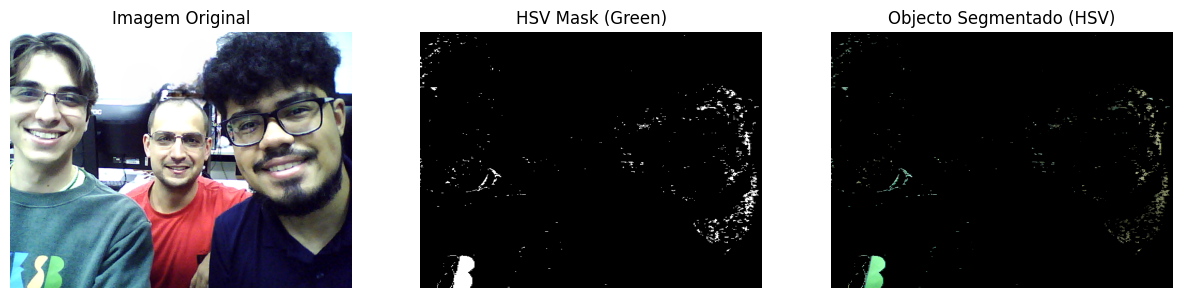

In [4]:
# Apresentação das etapas
# Obs. assumindo que a imagem 'img_bgr' já foi previamente gerada:
img = cv2.imread('img/alunos.png')
if img is not None:
    mask_hsv, segmented_object_hsv = segmentar_por_cor(img)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Imagem Original')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mask_hsv, cmap='gray')
    plt.title('HSV Mask (Green)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(segmented_object_hsv, cv2.COLOR_BGR2RGB))
    plt.title('Objecto Segmentado (HSV)')
    plt.axis('off')

    plt.show()
else:
    print("Error: 'img_bgr' is not defined. Please ensure the image is loaded first.")

### 3.5. Modelo $YCbCr$ (4.3.4)

Essencial para compressão de vídeo (MPEG, JPEG). Ele separa a Luminância ($Y$) da Crominância ($Cb$ e $Cr$).

A transformação padrão (BT.601) segue:


$$Y = 0.299R + 0.587G + 0.114B$$

$$Cb = 0.564(B - Y)$$

$$Cr = 0.713(R - Y)$$

In [ ]:
def rgb_to_ycbcr(rgb_img):
    # Coeficientes do livro (Seção 4.3.4)
    transform_mat = np.array([[0.299, 0.587, 0.114],
                              [-0.1687, -0.3313, 0.5],
                              [0.5, -0.4187, -0.0813]])
    # Ajuste de offset para Cb e Cr (normalmente 128 em 8 bits)
    ycbcr = rgb_img @ transform_mat.T
    ycbcr[:,:,1:] += 0.5
    return np.clip(ycbcr, 0, 1)

In [ ]:
# Apresentação dos canais Y, Cb, Cr:
# Obs. assumindo que a imagem 'img_rgb' já foi previamente gerada:
if 'img_rgb' in locals() and img_rgb is not None:
    # Aplicar a função rgb_to_ycbcr
    ycbcr_img = rgb_to_ycbcr(img_rgb)

    # Separar os canais Y, Cb e Cr
    Y_channel = ycbcr_img[:, :, 0]
    Cb_channel = ycbcr_img[:, :, 1]
    Cr_channel = ycbcr_img[:, :, 2]

    # Plotar a imagem original e os canais separados
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(img_rgb)
    plt.title('Imagem RGB Original')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(Y_channel, cmap='gray')
    plt.title('Y Channel (Luminancia)')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(Cb_channel, cmap='RdBu') # Red-Blue para Cb
    plt.title('Cb Crominancia (Blue-Yellow)')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(Cr_channel, cmap='PiYG') # Pink-Yellow-Green para Cr
    plt.title('Cr Crominancia (Red-Green)')
    plt.axis('off')

    plt.show()
else:
    print("Erro: 'img_rgb' não está definida. Por favor, carregue a imagem RGB primeiro.")

### Visualização de Decomposição de Cores dos canais **$L^*a^*b^*$** e **$YCbCr$**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def plot_color_decomposition(img_path):
    # Carregar imagem original (BGR) e converter para RGB para o Matplotlib
    bgr = cv2.imread(img_path)
    if bgr is None:
        print("Erro ao carregar a imagem.")
        return
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # 1. Transformação para LAB (Seção 4.1.14)
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2Lab)
    l_chan, a_chan, b_chan = cv2.split(lab)

    # 2. Transformação para YCbCr (Seção 4.3.4)
    ycbcr = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb) # OpenCV usa YCrCb por padrão
    y_chan, cr_chan, cb_chan = cv2.split(ycbcr)

    # Configuração do Plot
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    # Linha 1: Original e Espaço LAB
    axes[0, 0].imshow(rgb)
    axes[0, 0].set_title("Original (RGB)")
    axes[0, 1].imshow(l_chan, cmap='gray')
    axes[0, 1].set_title("LAB: Canal L* (Luminosidade)")
    axes[0, 2].imshow(a_chan, cmap='RdYlGn_r') # Red-Green para o eixo 'a'
    axes[0, 2].set_title("LAB: Canal a* (Verde-Vermelho)")

    # Linha 2: Continuação LAB e Espaço YCbCr
    axes[1, 0].imshow(b_chan, cmap='YlGnBu_r') # Yellow-Blue para o eixo 'b'
    axes[1, 0].set_title("LAB: Canal b* (Azul-Amarelo)")
    axes[1, 1].imshow(y_chan, cmap='gray')
    axes[1, 1].set_title("YCbCr: Canal Y (Luma)")
    axes[1, 2].imshow(cb_chan, cmap='jet')
    axes[1, 2].set_title("YCbCr: Canal Cb (Crominância Azul)")

    # Linha 3: Canal Cr e histogramas para análise
    axes[2, 0].imshow(cr_chan, cmap='jet')
    axes[2, 0].set_title("YCbCr: Canal Cr (Crominância Vermelha)")

    # Histograma de Luminância para comparar L* vs Y
    axes[2, 1].hist(l_chan.ravel(), bins=256, color='black', alpha=0.5, label='L*')
    axes[2, 1].hist(y_chan.ravel(), bins=256, color='blue', alpha=0.3, label='Y')
    axes[2, 1].set_title("Histograma: L* (LAB) vs Y (YCbCr)")
    axes[2, 1].legend()

    # Desativar eixos para as imagens
    for i in range(3):
        for j in range(3):
            if not (i == 2 and j == 1):
                axes[i, j].axis('off')

    plt.show()


In [ ]:
plot_color_decomposition('messi5.jpg')

---

## 4. Exercícios Propostos

(Elabore um código separamente para cas exercício)

1. **Comparação de Luminosidade:** Compare o canal $L^*$ do CIELAB com o canal $Y$ do $YCbCr$. Qual deles parece preservar melhor os detalhes de sombreamento da imagem original?
2. **Efeito Gama:** Aplique uma correção gama inversa ($\gamma = 2.2$) em uma imagem clara e observe a perda de detalhe nas áreas escuras.
3. **Filtro de Cor:** Use o espaço $YCbCr$ para remover a cor de uma imagem (torná-la escala de cinza) zerando os canais $Cb$ e $Cr$ e reconstruindo-a em $RGB$.

4. **O Desafio do Semáforo ou Objeto Colorido**
Escolha uma imagem que contenha objetos com as cores primárias bem definidas (ex: um semáforo, peças de LEGO ou frutas).

      (a). Tente segmentar um objeto específico usando o espaço **RGB** (definindo limites para R, G e B separadamente).

      (b). Realize a mesma segmentação usando o espaço **HSV**.

      (c). Compare os resultados: qual método foi mais fácil de configurar? Qual lidou melhor com as áreas de sombra do objeto?

Elabore aqui os programas para resolver os exercícios propostos.